In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import inspeqtor.experimental as sq
import seaborn as sns
import scienceplots as scienceplots
import gen_data_v2 as ml

In [2]:
colors = {"blue": "#6366f1", "red": "#f43f5e", "gray": "#4b5563"}

In [ ]:
TROTTER_STEPS = 2 ** 13
NOISE_STR = 0.01
DETUNE = 0.001
data_model = ml.get_data_model(
    noise_str=NOISE_STR, detune=DETUNE, trotter_steps=TROTTER_STEPS
)
control_sequence = data_model.control_sequence
qubit_info = data_model.qubit_information
_, l2a_fn = sq.control.get_param_array_converter(control_sequence)

signal_fn = sq.physics.signal_func_v5(
    get_envelope=sq.control.get_envelope_transformer(control_sequence=control_sequence),
    drive_frequency=qubit_info.frequency,
    dt=data_model.dt,
)

-0.033679667761885294


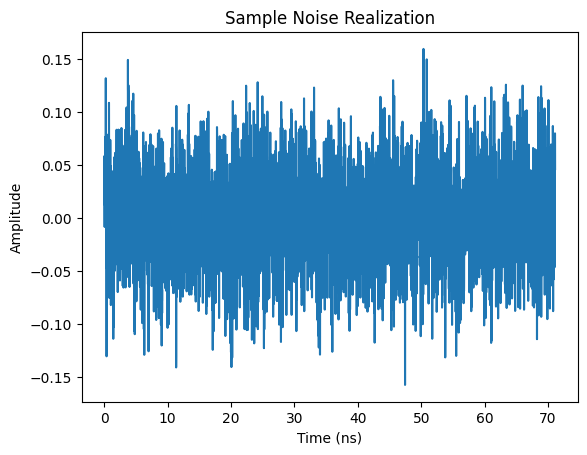

In [4]:
key = jax.random.key(4)
T = control_sequence.total_dt * data_model.dt  # Time(1 / T = dw)
nt = TROTTER_STEPS  # Num.of Discretized Time
F = 1 / T * nt / 2  # Frequency.(GHz)
nw = int(nt / 2)  # Num of Discretized Freq.
dt = T / nt
# time in nanosecond
t = jnp.linspace(0, T - dt, nt)
dw = F / nw
assert jnp.allclose(dw, 1 / T)
w = jnp.linspace(0, F - dw, nw)
spectrum = ml.get_PSD_v1()(w)
noise_fn = ml.make_noise_fn(spectrum, w, nt, dw)
key, subkey = jax.random.split(key)
sample = noise_fn(subkey)
plt.plot(t, NOISE_STR * sample)
plt.title("Sample Noise Realization")
plt.xlabel("Time (ns)")
plt.ylabel("Amplitude")

print(sample.mean())

Correlation Time (tau_c) from ACF Integral: 0.075 ns


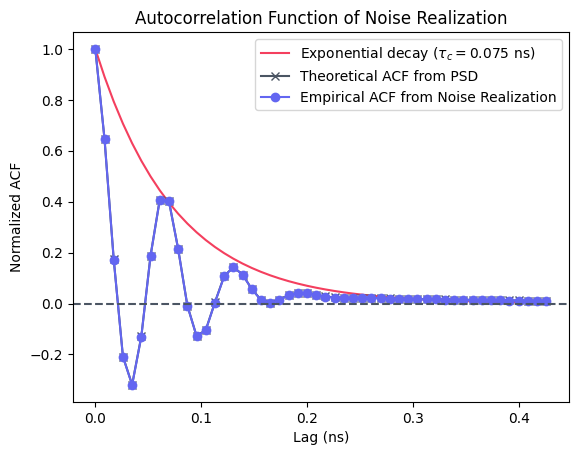

In [5]:
sample = noise_fn(jax.random.key(123))
# Scale your noise in the time domain
scaled_noise = NOISE_STR * sample

# # 1. Compute the Real FFT
# fft_output = jnp.fft.rfft(scaled_noise)

# # 2. Compute the PSD (Absolute Square eliminates the need for manual jnp.conj multiplication)
# psd = jnp.abs(fft_output) ** 2

# # 3. Compute the ACF using Inverse Real FFT (pass the original size)
# acf = jnp.fft.irfft(psd, n=sample.size)

# # 4. Normalize
# acf = acf / acf[0]

# (Alternative)
fft_output = jnp.fft.fft(scaled_noise)

acf = jnp.fft.ifft((fft_output) * jnp.conj(fft_output))
acf = acf / acf[0]  # Normalize so that R(0) = 1.0

# upper_limit = acf.size // 2
upper_limit = 50
lag = t[:upper_limit]
lag = jnp.arange(0, upper_limit) * (t[1] - t[0])

tau_c = 0.075
print(f"Correlation Time (tau_c) from ACF Integral: {tau_c:.3f} ns")

exponential_fit = jnp.exp(-lag / tau_c)
plt.plot(
    lag,
    exponential_fit,
    color=colors["red"],
    label=f"Exponential decay ($\\tau_c = {tau_c:.3f}$ ns)",
)

theo_acf = jnp.fft.irfft(spectrum)[: nt // 2]
theo_acf = theo_acf / theo_acf[0]  # Normalize so that R(0) = 1.0

plt.plot(
    lag,
    theo_acf[:upper_limit],
    "x-",
    color=colors["gray"],
    label="Theoretical ACF from PSD",
)
plt.plot(
    lag,
    acf[:upper_limit].real,
    "o-",
    color=colors["blue"],
    label="Empirical ACF from Noise Realization",
)
plt.xlabel("Lag (ns)")
plt.ylabel("Normalized ACF")
plt.axhline(0, color=colors["gray"], linestyle="--")
plt.title("Autocorrelation Function of Noise Realization")
plt.legend()

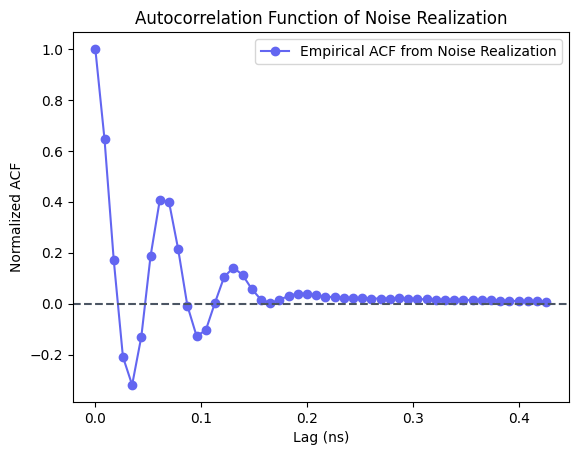

In [6]:
acf = jnp.correlate(scaled_noise, scaled_noise, mode="full")
acf = acf[acf.size // 2 :]  # Keep only non-negative lags
acf = acf / acf[0]  # Normalize so that R(0) = 1.0

# plt.plot(lag, theo_acf[:upper_limit], 'x-', color=colors["gray"], label="Theoretical ACF from PSD")
plt.plot(lag, acf[:upper_limit].real, 'o-', color=colors["blue"], label="Empirical ACF from Noise Realization")
plt.xlabel("Lag (ns)")
plt.ylabel("Normalized ACF")
plt.axhline(0, color=colors["gray"], linestyle="--")
plt.title("Autocorrelation Function of Noise Realization")
plt.legend()

In [7]:
import jax
import jax.numpy as jnp

def estimate_tau_c_model_independent(lag_axis, normalized_acf):
    """
    Computes the characteristic correlation time without any curve fitting
    by calculating the area under the absolute value of the ACF.
    """
    # 1. Take the absolute value to prevent oscillating valleys from canceling peaks
    abs_acf = jnp.abs(normalized_acf)
    
    # 2. Extract the exact time-step size (dt) from your lag axis
    dt = lag_axis[1] - lag_axis[0]
    
    # 3. Integrate across the entire valid decay window using trapezoidal rule
    tau_c = jnp.trapezoid(abs_acf, dx=dt)
    
    return tau_c

# --- How to use it on your clean, theoretical background ---
# 1. Compute the pristine ACF from your smooth Input PSD vector
# clean_acf = jnp.fft.irfft(smooth_input_psd)
# clean_acf_normalized = clean_acf / clean_acf[0]

acf = jnp.fft.irfft(spectrum)[: nt // 2]
acf = acf / acf[0]  # Normalize so that R(0) = 1.0

# 2. Calculate tau_c directly
robust_tau_c = estimate_tau_c_model_independent(lag, acf[:upper_limit])
print(f"True Model-Independent Characteristic Time: {robust_tau_c:.4f} ns")

True Model-Independent Characteristic Time: 0.0388 ns


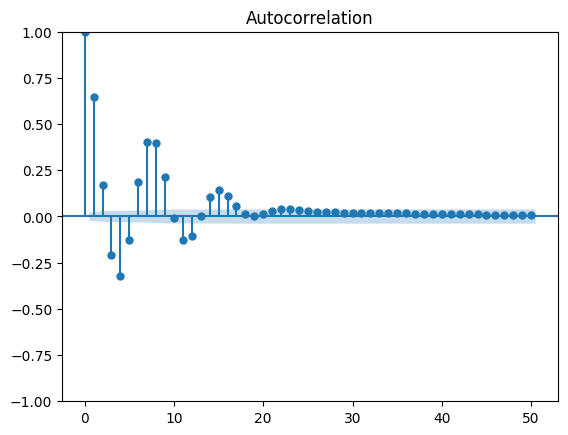

In [8]:
import statsmodels.api as sm

fig = sm.graphics.tsa.plot_acf(scaled_noise, lags=50)

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Run the test
result = adfuller(scaled_noise)

print(f'ADF Statistic: {result[0]}')
print(f'p-value: {result[1]}')
print(f'Used Lag: {result[2]}')
print('Critical Values:')
for key, value in result[4].items(): # type: ignore
    print(f'   {key}: {value}')

ADF Statistic: -16.664127183427993
p-value: 1.5649756594184766e-29
Used Lag: 16
Critical Values:
   1%: -3.431150165690753
   5%: -2.861893616944296
   10%: -2.566958225517867


Correlation Time (tau_c) from ACF Integral: 0.075 ns


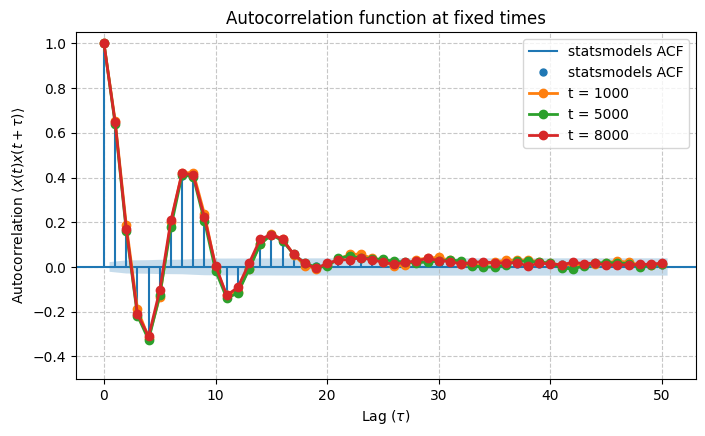

In [15]:
key = jax.random.key(123)
samples = NOISE_STR * jax.vmap(noise_fn)(jax.random.split(key, num=10000))


def autocorrelation_fn(t, tau):
    x_t = samples[:, t]
    x_t_tau = samples[:, t + tau]

    return jnp.mean(x_t * x_t_tau)


max_tau = 50
tau_values = jnp.arange(0, max_tau + 1)

t_fixed_values = [1000, 5000, 8000]

acf_values = {}
for t_fixed in t_fixed_values:
    acf_values[t_fixed] = jax.vmap(lambda tau: autocorrelation_fn(t_fixed, tau))(
        tau_values
    )
    acf_values[t_fixed] = (
        acf_values[t_fixed] / acf_values[t_fixed][0]
    )  # Normalize so that ACF(0) = 1.0

# --- PLOTTING ---
fig, ax = plt.subplots(figsize=(8, 4.5))

# From particular noise realization using statsmodels
sm.graphics.tsa.plot_acf(
    scaled_noise, lags=50, ax=ax, label="statsmodels ACF"
)

for t_fixed in t_fixed_values:
    ax.plot(
        tau_values, acf_values[t_fixed], marker="o", linewidth=2, label=f"t = {t_fixed}"
    )

tau_c_ns = 0.075
lag = jnp.arange(0, max_tau + 1) * (t[1] - t[0])
tau_c = tau_c_ns / (lag[1] - lag[0])
print(f"Correlation Time (tau_c) from ACF Integral: {tau_c_ns:.3f} ns")

# exponential_model = jnp.exp(-tau_values / tau_c)
# ax.plot(
#     tau_values,
#     exponential_model,
#     color="tab:purple",
#     label=f"Exponential decay ($\\tau_c = {tau_c:.3f} \\rightarrow {tau_c_ns:.3f}$ ns)",
# )

ax.set_title("Autocorrelation function at fixed times")
ax.set_xlabel(r"Lag ($\tau$)")
ax.set_ylabel(r"Autocorrelation $\langle x(t)x(t+\tau) \rangle$")
ax.grid(True, linestyle="--", alpha=0.7)
ax.set_ylim(-0.5, 1.05)
ax.legend()
fig.savefig("fig_acf_fixed_times.pdf", dpi=300, bbox_inches="tight")
plt.show()

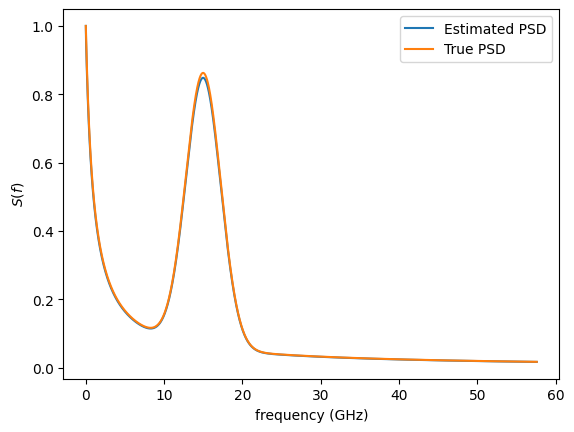

In [11]:
def estimate_psd(key):
    sample = NOISE_STR * noise_fn(key)
    A = jnp.fft.fft(sample)
    psd = jnp.abs(A) ** 2
    return psd  # Keep it raw and unnormalized here

num_samples = 1000
# 1. Compute all raw power spectral densities across realizations
raw_psds = jax.vmap(estimate_psd)(jax.random.split(jax.random.key(123), num_samples))

# 2. Take the ensemble average first
mean_psd = raw_psds.mean(axis=0)

# 3. Slice out just the positive frequencies (one-sided length)
estimated_one_sided = mean_psd[:nw]

# ====================================================================
# Recombine positive and negative frequency power.
# We multiply every element by 2.0, EXCEPT for the first element (f=0).
# https://www.mathworks.com/help/signal/ug/power-spectral-density-estimates-using-fft.html
# ====================================================================
power_multiplier = jnp.ones(nw).at[1:].set(2.0)
estimated_one_sided_corrected = estimated_one_sided * power_multiplier

# 4. Globally normalize the corrected one-sided curve at the very end
estimated_psd_normalized = estimated_one_sided_corrected / estimated_one_sided_corrected.max()

# 4. Plot the corrected results
plt.plot(w, estimated_psd_normalized[:nw], label="Estimated PSD")
plt.plot(w, spectrum, label="True PSD")
plt.xlabel("frequency (GHz)")
plt.ylabel("$S(f)$")
plt.legend()

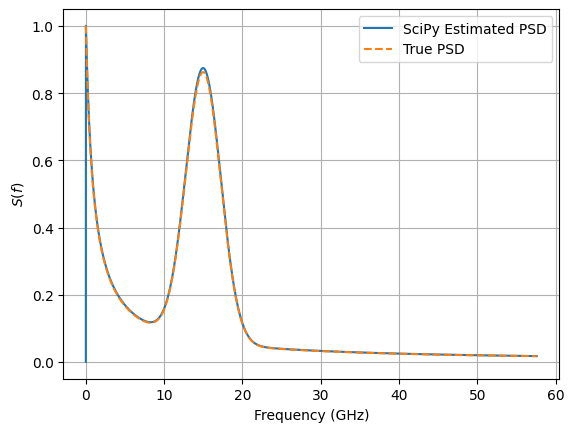

In [12]:
import jax
import jax.numpy as jnp
import numpy as np
import scipy.signal as signal
import matplotlib.pyplot as plt

# 1. Grab your time parameters
# Let's say your time-step dt is 0.002 ns
dt = t[1] - t[0]  # Extract the actual time-step from your time vector
fs = float(1.0 / dt)  # Sampling frequency (in GHz if dt is in ns)

# 2. Generate your noise realizations using your existing JAX setup
num_samples = 1000
# (Assuming your noise function takes a key and returns a time-series noise sample)
raw_noise_samples = NOISE_STR * jax.vmap(noise_fn)(jax.random.split(jax.random.key(123), num_samples))

# Convert the JAX ensemble array to a standard NumPy array for SciPy
# Shape should be (num_samples, time_steps)
noise_matrix_np = np.asarray(raw_noise_samples)

# ====================================================================
# THE SCIPY SHORTCUT
# axis=-1 runs the PSD independently across each noise realization row.
# scaling='density' ensures it calculates a proper Power Spectral Density.
# ====================================================================
frequencies, psd_matrix = signal.periodogram(
    noise_matrix_np, 
    fs=fs, 
    scaling='density', 
    axis=-1
)

# 3. Take the ensemble average across all 1000 realizations to smooth the curve
mean_psd = psd_matrix.mean(axis=0)

# 4. Globally normalize it to match your True PSD format
estimated_psd_normalized = mean_psd / mean_psd.max()

# ====================================================================
# PLOT THE RESULTS
# ====================================================================
# Slice up to your 'nw' limit (e.g., 70 GHz) to view the relevant window
plt.plot(frequencies[:nw], estimated_psd_normalized[:nw], label="SciPy Estimated PSD")
plt.plot(w, spectrum, label="True PSD", linestyle="--")
plt.xlabel("Frequency (GHz)")
plt.ylabel("$S(f)$")
plt.legend()
plt.grid(True)
plt.show()

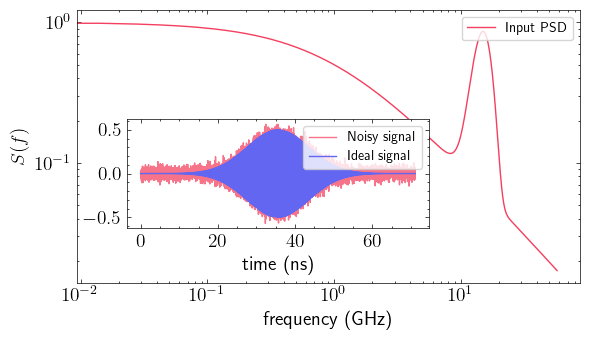

In [36]:
with plt.style.context("science"):
    fontsize = 14
    fig, ax = plt.subplots(figsize=(6, 3.5))

    # y = 1 / (w + 1)
    # ax.loglog(w, y, color=colors["gray"], label="Example $1/f$ PSD")

    ax.loglog(np.array(w), np.array(spectrum), color=colors["red"], label="Input PSD")
    ax.set_xlabel("frequency (GHz)")
    ax.set_ylabel("$S(f)$")
    params = jnp.array([2 * jnp.pi])

    noisy_signal = signal_fn(params, t) + NOISE_STR * noise_fn(subkey)

    inset_ax = ax.inset_axes((0.1, 0.20, 0.6, 0.4))
    inset_ax.plot(
        t, noisy_signal, color=colors["red"], alpha=0.73, label="Noisy signal"
    )
    inset_ax.plot(t, signal_fn(params, t), color=colors["blue"], label="Ideal signal")
    inset_ax.set_xlabel("time (ns)")
    sq.visualization.set_fontsize(ax, fontsize)
    sq.visualization.set_fontsize(inset_ax, fontsize)

    ax.legend(loc="upper right", frameon=True)
    inset_ax.legend(loc="upper right", frameon=True)

fig.tight_layout()
fig.savefig("fig_psd_profile_and_signal.pdf")

Text(0.5, 1.0, 'Autocorrelation Function from Theoretical PSD')

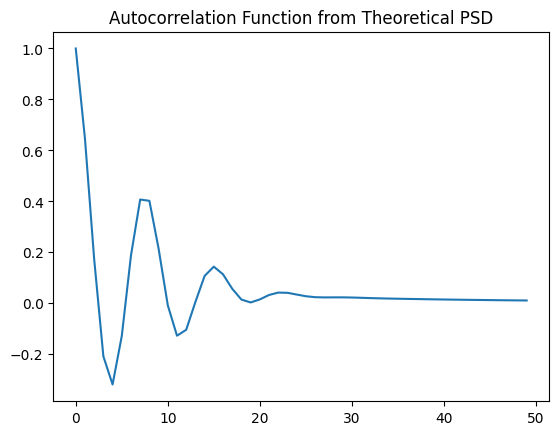

In [14]:
acf = jnp.fft.irfft(spectrum)[: nt // 2]
acf = acf / acf[0]  # Normalize so that R(0) = 1.0
plt.plot(acf[:50])
plt.title("Autocorrelation Function from Theoretical PSD")

In [18]:
def simulate(
    key, params=jnp.array([jnp.pi / 3]), noise_str=0.01, N_UNITARY_SAMPLES=1000
):
    SHOTS = 10000
    SAMPLE_SIZE = 1000

    y0 = jnp.eye(2, dtype=jnp.complex128)

    noisy_signal_fn = ml.make_noisy_signal_fn(
        signal_fn, t, spectrum, w, noise_str=noise_str, dw=dw
    )
    hamiltonian = ml.make_noisy_hamiltonian(
        t, qubit_info, noisy_signal_fn, detune=DETUNE
    )
    stochastic_solver = ml.make_final_returned_whitebox_fn(
        ml.make_stochastic_trotterization_solver(hamiltonian, t, y0)
    )

    unitaries = ml.make_prepare_unitary_ensemble(stochastic_solver, N_UNITARY_SAMPLES)(
        key, params
    )
    initial_state = sq.data.State.from_label("1", dm=True)
    observable = sq.data.Operator.from_label("Z")

    intermediate_expval = sq.physics.calculate_exp(
        unitaries, operator=observable, density_matrix=initial_state
    )
    probs = sq.utils.expectation_value_to_prob_plus(intermediate_expval)

    key, subkey = jax.random.split(key)
    sim = jax.vmap(ml.simulate_the_shot, in_axes=(0, None))(
        jax.random.split(subkey, int(SAMPLE_SIZE * SHOTS)), probs
    )

    stochastic_expval_sample = sim.reshape(SAMPLE_SIZE, SHOTS).mean(1)

    theoretical_stochastic_variance = sq.utils.variance_of_observable(
        intermediate_expval.mean(), SHOTS
    )
    print(f"Theoreitical variance: {theoretical_stochastic_variance:.5f} ")
    print(f"The distribution of Probability: {probs.mean():.5f} {probs.std():.5f}")
    print(
        f"The finite-shot expectation value and the variance: {stochastic_expval_sample.mean():3f} {stochastic_expval_sample.var():3f}",
    )
    return intermediate_expval, stochastic_expval_sample


In [19]:
key, subkey = jax.random.split(key)
deterministic_intermediate_expval, deterministic_expval_sample = simulate(
    subkey, params, noise_str=0.0
)

Theoreitical variance: 0.00000 
The distribution of Probability: 0.00504 0.00000
The finite-shot expectation value and the variance: -0.989891 0.000002


In [20]:
key, subkey = jax.random.split(key)
weak_stoc_intermediate_expval, weak_stoc_expval_sample = simulate(
    subkey, params, noise_str=0.01
)

Theoreitical variance: 0.00000 
The distribution of Probability: 0.00547 0.00221
The finite-shot expectation value and the variance: -0.989076 0.000002


In [21]:
key, subkey = jax.random.split(key)
strong_stoc_intermediate_expval, strong_stoc_expval_sample = simulate(
    subkey, params, noise_str=0.05
)

Theoreitical variance: 0.00001 
The distribution of Probability: 0.01585 0.01418
The finite-shot expectation value and the variance: -0.968426 0.000006


In [22]:
from matplotlib.ticker import MaxNLocator, MultipleLocator

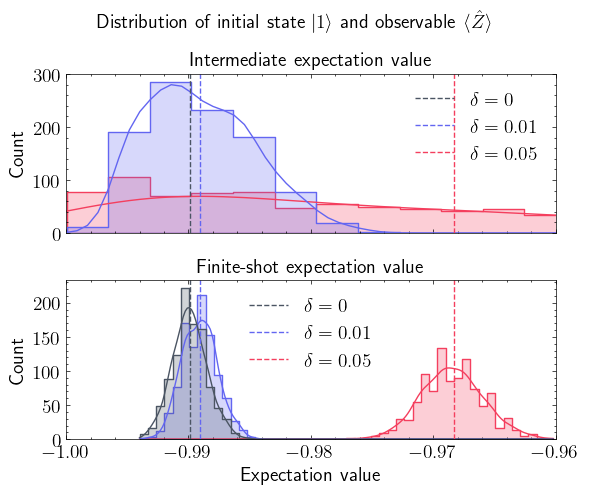

In [23]:
stochastic_weak_text = r"$\delta = 0.01$"
stochastic_strong_text = r"$\delta = 0.05$"

with plt.style.context("science"):
    fig, axes = plt.subplots(2, 1, figsize=(6, 5), sharex=True)
    axes = sq.visualization.assert_list_of_axes(axes)

    sns.histplot(
        {
            stochastic_weak_text: weak_stoc_intermediate_expval,
            stochastic_strong_text: strong_stoc_intermediate_expval,
        },
        element="step",
        kde=True,
        bins=50,
        ax=axes[0],
        fill=True,
        palette={
            stochastic_weak_text: colors["blue"],
            stochastic_strong_text: colors["red"],
        },
    )

    sns.histplot(
        {
            "deterministic": deterministic_expval_sample,
            stochastic_weak_text: weak_stoc_expval_sample,
            stochastic_strong_text: strong_stoc_expval_sample,
        },
        element="step",
        kde=True,
        ax=axes[1],
        bins=50,
        palette={
            "deterministic": colors["gray"],
            stochastic_weak_text: colors["blue"],
            stochastic_strong_text: colors["red"],
        },
    )

    axes[0].set_title(r"Intermediate expectation value")
    axes[1].set_title(r"Finite-shot expectation value")

    axes[0].set_xlim(-1, -0.96)
    axes[1].set_xlim(-1, -0.96)
    axes[1].set_xlabel("Expectation value")
    # axes[1].set_xticks([-0.99, -0.98, -0.97])
    axes[1].xaxis.set_major_locator(MaxNLocator(nbins=4))
    axes[1].xaxis.set_major_locator(MultipleLocator(0.01))  # Tick every 0.01

    for ax in axes:
        ax.axvline(
            deterministic_intermediate_expval.mean().item(),
            label=r"$\delta = 0$",
            color=colors["gray"],
            linestyle="dashed",
        )

        ax.axvline(
            weak_stoc_intermediate_expval.mean().item(),
            label=stochastic_weak_text,
            color=colors["blue"],
            linestyle="dashed",
        )

        ax.axvline(
            strong_stoc_intermediate_expval.mean().item(),
            label=stochastic_strong_text,
            color=colors["red"],
            linestyle="dashed",
        )

        sq.visualization.set_fontsize(ax, fontsize)
        # ax.legend()

    fig.suptitle(
        r"Distribution of initial state $|1\rangle$ and observable $\langle \hat{Z} \rangle$",
        fontsize=fontsize,
    )
    fig.tight_layout()
fig.savefig("fig_shift.pdf")